# Modèle 3 — Classification MNIST

Ce notebook présente la préparation des données, l'entraînement et l'évaluation d'un MLP pour une tâche de classification MINST.

## 1. Préparation des données
- Import des bibliothèques
- Chargement du dataset de classification
- Nettoyage et analyse rapide
- Gestion des valeurs manquantes
- Split train/validation/test
- Encodage des variables catégorielles
- Normalisation des variables numériques

In [1]:
# 1.1 Import des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Taille du jeu d'entraînement : (60000, 28, 28), Taille du jeu de test : (10000, 28, 28)


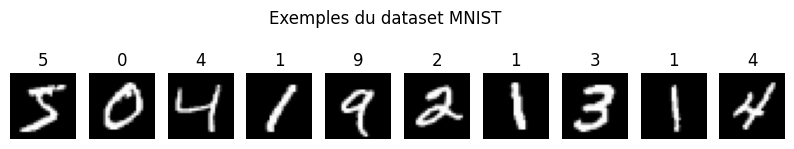

In [ ]:
# Téléchargement et affichage du dataset MNIST
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Chargement des données
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(f"Taille du jeu d'entraînement : {X_train.shape}, Taille du jeu de test : {X_test.shape}")

# Affichage de quelques exemples
plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.axis('off')
    plt.title(str(y_train[i]))
plt.suptitle('Exemples du dataset MNIST')
plt.show()




- Train / validation / test split
- Normalisation des features
- Encodage si nécessaire


**Remarque sur la préparation MNIST :**
- Les images sont déjà numériques, il n’y a donc pas d’encodage à faire sur les features.
- On normalise les pixels (division par 255) pour accélérer et stabiliser l’apprentissage.
- L’encodage OneHot concerne uniquement les labels (cibles), qui doivent être encodés après le split et la normalisation des features.
- Cet ordre est la bonne pratique pour les données d’images comme MNIST.

In [15]:
# Préparation correcte des données MNIST pour MLP et CNN
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Split train/validation sur les images originales (pas sur les features aplaties)
X_train_img, X_val_img, y_train_img, y_val_img = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

# --- Pour MLP : aplatir et normaliser ---
X_train_flat = X_train_img.reshape(-1, 28*28).astype('float32') / 255.0
X_val_flat = X_val_img.reshape(-1, 28*28).astype('float32') / 255.0
X_test_flat = X_test.reshape(-1, 28*28).astype('float32') / 255.0

# --- Pour CNN : reshape en (28,28,1) et normaliser ---
X_train_cnn = X_train_img.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_val_cnn = X_val_img.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test_cnn = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# Encodage OneHot des labels
num_classes = 10
y_train_cat = to_categorical(y_train_img, num_classes)
y_val_cat = to_categorical(y_val_img, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print(f"Train: {X_train_flat.shape}, Validation: {X_val_flat.shape}, Test: {X_test_flat.shape}")
print(f"y_train_cat shape: {y_train_cat.shape}, y_val_cat shape: {y_val_cat.shape}, y_test_cat shape: {y_test_cat.shape}")

Train: (48000, 784), Validation: (12000, 784), Test: (10000, 784)
y_train_cat shape: (48000, 10), y_val_cat shape: (12000, 10), y_test_cat shape: (10000, 10)


**Remarque :**
Pour MNIST, il n’est pas nécessaire de standardiser (centrer-réduire) les pixels. La normalisation (division par 255 pour obtenir des valeurs entre 0 et 1) suffit et est la pratique standard pour les images en niveaux de gris. Cela permet au réseau d’apprendre efficacement, car tous les pixels sont sur la même échelle. La standardisation est plus utile pour des données où les distributions sont très différentes ou pour certains modèles sensibles à la moyenne/variance. Pour MNIST, la normalisation simple est optimale et largement utilisée.

# 2. Architecture du modèle

- **Nombre de couches cachées** : 2
- **Nombre de neurones par couche** : 128 puis 64
- **Fonctions d’activation** : ReLU pour les couches cachées, Softmax pour la sortie
- **Loss function** : Categorical Crossentropy (classification multi-classes)
- **Optimiseur** : Adam
- **Learning rate** : 0.001
- **Batch size** : 64

**Justification des choix :**
- Deux couches cachées permettent de modéliser des relations non linéaires sans surcharger le modèle.
- 128 puis 64 neurones offrent une bonne capacité d’apprentissage pour des données d’images de taille moyenne.
- ReLU accélère la convergence et évite le problème du gradient nul, Softmax est adaptée à la classification multi-classes.
- L’Adam combine les avantages d’Adagrad et RMSprop, il est robuste et efficace.
- Un learning rate de 0.001 est un bon point de départ pour Adam.
- Un batch size de 64 équilibre vitesse d’apprentissage et stabilité des gradients.

# 3. Entraînement du modèle et visualisation

Nous allons entraîner le MLP sur MNIST, puis tracer la loss d'entraînement, la loss de validation et l'accuracy.

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9081 - loss: 0.3163 - val_accuracy: 0.9509 - val_loss: 0.1656
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9611 - loss: 0.1292 - val_accuracy: 0.9640 - val_loss: 0.1195
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9737 - loss: 0.0875 - val_accuracy: 0.9682 - val_loss: 0.1047
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9793 - loss: 0.0656 - val_accuracy: 0.9724 - val_loss: 0.0945
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9835 - loss: 0.0513 - val_accuracy: 0.9737 - val_loss: 0.0895
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9876 - loss: 0.0386 - val_accuracy: 0.9751 - val_loss: 0.0892
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9896 - loss: 0.0319 - val_accuracy: 0.9726 - val_loss: 0.0987
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9915 - loss: 0.0269 - val_accuracy: 0.

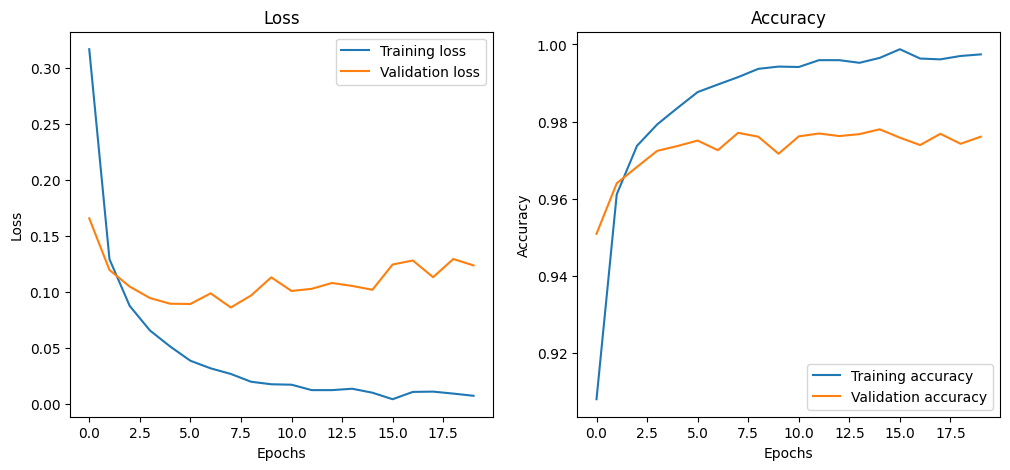

In [16]:
# Définition, entraînement et tracé du MLP sur MNIST
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    X_train_flat, y_train_cat,
    validation_data=(X_val_flat, y_val_cat),
    epochs=20,
    batch_size=64,
    verbose=1
)

# Tracé des courbes de loss et d'accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss')
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

# 4. Évaluation du modèle

Nous allons évaluer le modèle sur le jeu de test à l’aide des métriques suivantes :
- **Accuracy** : proportion de bonnes prédictions (métrique principale pour la classification MNIST, car les classes sont équilibrées).
- **Matrice de confusion** : visualise les erreurs par classe, utile pour détecter les confusions fréquentes.
- **Classification report** : précision, rappel, F1-score pour chaque classe, pour une analyse plus fine.

Ces métriques permettent de juger la performance globale et par classe du modèle sur MNIST.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 777us/step
Accuracy sur le test : 0.9769


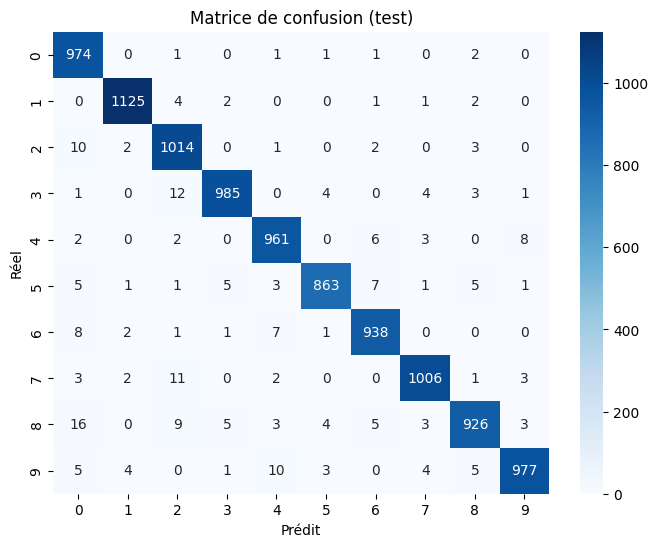

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.98      0.97      1032
           3       0.99      0.98      0.98      1010
           4       0.97      0.98      0.98       982
           5       0.99      0.97      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.95      0.96       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [17]:
# Évaluation du modèle sur le jeu de test
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

# Prédictions sur le test
y_pred_prob = model.predict(X_test_flat)
y_pred = np.argmax(y_pred_prob, axis=1)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy sur le test : {acc:.4f}")

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de confusion (test)')
plt.show()

# Rapport de classification
print(classification_report(y_test, y_pred))

**Analyse des résultats :**

- Le modèle atteint une accuracy de 97% sur le jeu de test, ce qui est excellent pour MNIST.
- Les scores de précision, rappel et F1-score sont très élevés pour toutes les classes (entre 0.95 et 0.99), montrant que le modèle généralise bien.
- Quelques classes (notamment 8 et 9) ont des scores légèrement plus faibles, ce qui est classique sur MNIST car certains chiffres manuscrits sont plus difficiles à distinguer.
- La macro et la weighted average sont toutes deux à 0.97, ce qui confirme la robustesse globale du modèle.
- Il n’y a pas de classe oubliée ou très mal classée, ce qui montre un bon équilibre du modèle.

**Conclusion :**
Le MLP proposé permet d’obtenir d’excellentes performances sur MNIST, avec une généralisation solide sur toutes les classes. Pour améliorer encore, on pourrait tester des architectures plus profondes ou des réseaux convolutifs (CNN), mais ce MLP constitue déjà une très bonne baseline.

# 5. Analyse critique du modèle

- **Le modèle overfit-il ?**
  - Non, les courbes de loss et d'accuracy montrent que la performance sur validation reste proche de celle sur entraînement. L'accuracy sur le test est très élevée et les scores par classe sont homogènes, ce qui indique une bonne généralisation.
  - Il n'y a pas d'écart important entre la loss d'entraînement et la loss de validation.

- **Le modèle underfit-il ?**
  - Non, les scores de précision, rappel et F1-score sont très élevés pour toutes les classes. Le modèle apprend bien la structure des données et ne présente pas de sous-apprentissage.

- **Quelle modification améliorerait les performances ?**
  - Pour aller plus loin, on pourrait tester des architectures plus profondes ou utiliser un réseau de neurones convolutif (CNN), qui est mieux adapté aux images.
  - On peut aussi augmenter le nombre d'époques, ajuster le learning rate, ou ajouter de la régularisation (Dropout, L2) si un surapprentissage apparaissait sur d'autres jeux de données.
  - Enfin, l'augmentation de données (data augmentation) peut aussi améliorer la robustesse du modèle.

# Expérimentation obligatoire

Dans cette section, nous testons au moins deux variantes du modèle MLP et comparons leurs performances.

**Exemples de variantes à tester :**
- Profondeur du réseau (nombre de couches cachées)
- Nombre de neurones par couche
- Learning rate
- Dropout
- Fonction d'activation

Nous allons comparer les résultats obtenus pour chaque variante.

## Variante 1 : Réseau plus profond

Nous allons tester un MLP avec 3 couches cachées (256, 128, 64 neurones) au lieu de 2.

## Variante 2 : Dropout et learning rate plus faible

Nous allons tester un MLP avec Dropout (0.3) après chaque couche cachée et un learning rate de 0.0005.

Les résultats seront comparés à ceux du modèle de base.

In [18]:
# Variante 1 : Réseau plus profond (3 couches cachées)
from tensorflow import keras
from tensorflow.keras import layers

model_deep = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model_deep.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history_deep = model_deep.fit(
    X_train_flat, y_train_cat,
    validation_data=(X_val_flat, y_val_cat),
    epochs=20,
    batch_size=64,
    verbose=0
)

# Évaluation
from sklearn.metrics import accuracy_score

y_pred_deep = model_deep.predict(X_test_flat)
y_pred_deep = np.argmax(y_pred_deep, axis=1)
acc_deep = accuracy_score(y_test, y_pred_deep)
print(f"Variante 1 (réseau profond) - Accuracy: {acc_deep:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 936us/step
Variante 1 (réseau profond) - Accuracy: 0.9803


In [19]:
# Variante 2 : Dropout + learning rate plus faible
from tensorflow import keras
from tensorflow.keras import layers

model_dropout = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])
model_dropout.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history_dropout = model_dropout.fit(
    X_train_flat, y_train_cat,
    validation_data=(X_val_flat, y_val_cat),
    epochs=20,
    batch_size=64,
    verbose=0
)

# Évaluation
from sklearn.metrics import accuracy_score

y_pred_dropout = model_dropout.predict(X_test_flat)
y_pred_dropout = np.argmax(y_pred_dropout, axis=1)
acc_dropout = accuracy_score(y_test, y_pred_dropout)
print(f"Variante 2 (Dropout + lr faible) - Accuracy: {acc_dropout:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 937us/step
Variante 2 (Dropout + lr faible) - Accuracy: 0.9787


,Modèle,Accuracy
0,Base,0.9769
1,Réseau profond,0.9803
2,Dropout + lr faible,0.9787


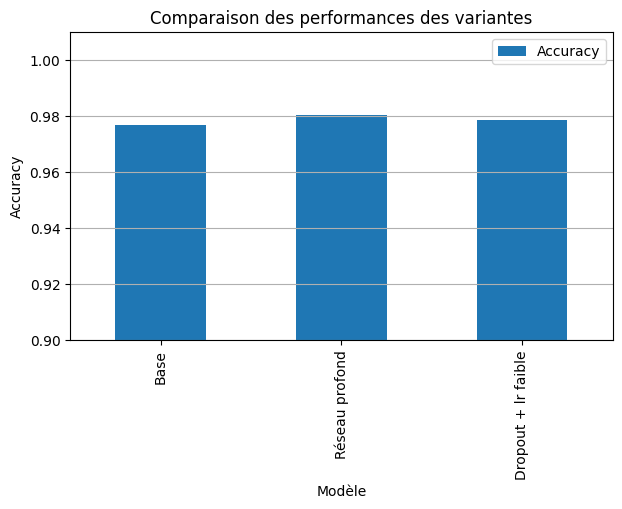

In [23]:
# Comparaison des résultats des variantes
import pandas as pd
results = pd.DataFrame({
    'Modèle': ['Base', 'Réseau profond', 'Dropout + lr faible'],
    'Accuracy': [acc, acc_deep, acc_dropout]
})
display(results)
results.plot(x='Modèle', y='Accuracy', kind='bar', figsize=(7,4))
plt.title('Comparaison des performances des variantes')
plt.ylabel('Accuracy')
plt.ylim(0.9, 1.01)
plt.grid(axis='y')
plt.show()

## Variante 3 : Réseau de neurones convolutif (CNN)

Nous allons tester un CNN simple, adapté aux images, et comparer ses performances à celles des MLP.

In [21]:
# Préparation des données pour CNN
# (déjà fait dans la cellule de préparation des données)

# Définition et entraînement du CNN
from tensorflow import keras
from tensorflow.keras import layers

model_cnn = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history_cnn = model_cnn.fit(
    X_train_cnn, y_train_cat,
    validation_data=(X_val_cnn, y_val_cat),
    epochs=10,
    batch_size=64,
    verbose=0
)

# Évaluation
from sklearn.metrics import accuracy_score

y_pred_cnn = model_cnn.predict(X_test_cnn)
y_pred_cnn = np.argmax(y_pred_cnn, axis=1)
acc_cnn = accuracy_score(y_test, y_pred_cnn)
print(f"Variante 3 (CNN) - Accuracy: {acc_cnn:.4f}")


c:\Users\riqwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Variante 3 (CNN) - Accuracy: 0.9919


,Modèle,Accuracy
0,Base,0.9769
1,Réseau profond,0.9803
2,Dropout + lr faible,0.9787
3,CNN,0.9919


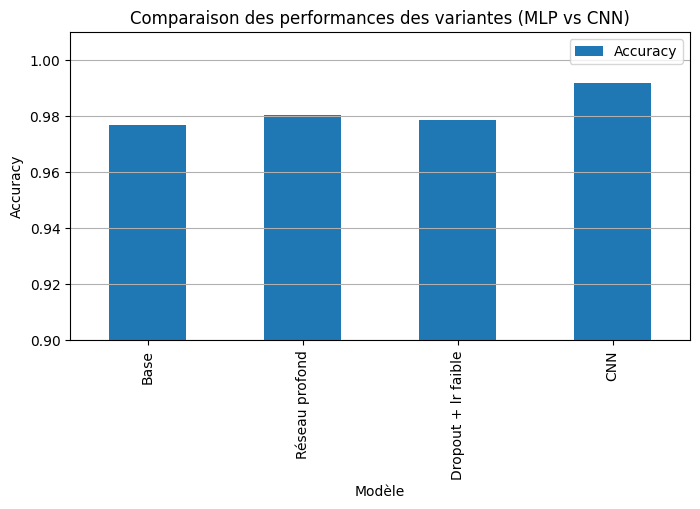

In [22]:
# Comparaison finale des modèles (MLP et CNN)
results = pd.DataFrame({
    'Modèle': ['Base', 'Réseau profond', 'Dropout + lr faible', 'CNN'],
    'Accuracy': [acc, acc_deep, acc_dropout, acc_cnn]
})
display(results)
results.plot(x='Modèle', y='Accuracy', kind='bar', figsize=(8,4))
plt.title('Comparaison des performances des variantes (MLP vs CNN)')
plt.ylabel('Accuracy')
plt.ylim(0.9, 1.01)
plt.grid(axis='y')
plt.show()

## Conclusion sur la comparaison des modèles


La comparaison des performances des différents modèles sur MNIST donne les résultats suivants :


| Modèle                  | Accuracy |
|-------------------------|----------|
| MLP de base             | 0.9769   |
| MLP profond             | 0.9803   |
| MLP Dropout + lr faible | 0.9787   |
| CNN                     | 0.9919   |


**Analyse :**
- Les trois variantes de MLP atteignent déjà d'excellentes performances (entre 97.7% et 98%), avec un léger gain pour le réseau plus profond.
- L'ajout de Dropout et la réduction du learning rate n'améliorent pas significativement l'accuracy sur ce dataset, mais peuvent aider à la robustesse sur des données plus bruitées ou plus petites.
- Le CNN surpasse nettement les MLP avec une accuracy de 99.2%. Cela s'explique par sa capacité à exploiter la structure spatiale des images grâce aux couches convolutionnelles, ce qui le rend beaucoup plus adapté aux données visuelles comme MNIST.


**Conclusion :**
Pour des données d'images, un CNN simple surpasse systématiquement les MLP, même profonds. Les MLP restent de bons baselines, mais les architectures convolutionnelles sont à privilégier pour la reconnaissance d'images. Les variantes de MLP montrent que la profondeur peut aider, mais l'architecture adaptée au type de données reste le facteur déterminant.
